# Phần 1: Khai phá luật kết hợp (Association Rules)
Mục tiêu: Tìm ra các tổ hợp yếu tố (nguyên nhân) dẫn đến việc nhân viên nghỉ việc (Leave) và ở lại (Stay).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import joblib
import warnings

# Tắt các cảnh báo màu hồng chướng mắt
warnings.filterwarnings('ignore')

# Căn chỉnh lại thư mục gốc để đọc file
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

print("1. Đang đọc dữ liệu đã rời rạc hóa...")
# Đọc dữ liệu từ thư mục processed
df_rules = pd.read_csv('data/processed/hr_rules_binned.csv')

# Chuyển đổi dữ liệu sang định dạng One-hot (Boolean) cho mlxtend
df_transactions = pd.get_dummies(df_rules).astype(bool)
print(f"-> Kích thước ma trận giao dịch (Transactions): {df_transactions.shape}")

1. Đang đọc dữ liệu đã rời rạc hóa...
-> Kích thước ma trận giao dịch (Transactions): (1416, 71)


# Chạy thuật toán FP-Growth & Trích xuất luật

In [18]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

print("2. Đang chạy thuật toán FP-Growth tìm tập phổ biến...")
frequent_itemsets = fpgrowth(df_transactions, min_support=0.15, use_colnames=True, max_len=3)
print(f"-> Tìm thấy {len(frequent_itemsets)} tập phổ biến.")

print("3. Đang sinh luật kết hợp và tính toán các chỉ số (Support, Confidence, Lift)...")
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print(f"-> Sinh ra được {len(rules)} luật kết hợp.")

2. Đang chạy thuật toán FP-Growth tìm tập phổ biến...
-> Tìm thấy 10658 tập phổ biến.
3. Đang sinh luật kết hợp và tính toán các chỉ số (Support, Confidence, Lift)...
-> Sinh ra được 46880 luật kết hợp.


# So sánh nguyên nhân Nghỉ việc (Leave) vs Ở lại (Stay)

In [19]:
# Lọc các luật có Vế phải (Consequents) là Nghỉ việc
leave_rules = rules[
    rules['consequents'] == frozenset({'Attrition_Status_Leave'})
].sort_values(by='lift', ascending=False)

# Lọc các luật có Vế phải (Consequents) là Ở lại
stay_rules = rules[
    rules['consequents'] == frozenset({'Attrition_Status_Stay'})
].sort_values(by='lift', ascending=False)

print("🔴 TOP 5 TỔ HỢP NGUYÊN NHÂN DẪN ĐẾN NGHỈ VIỆC (LEAVE)")
display(leave_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

print("\n🟢 TOP 5 TỔ HỢP NGUYÊN NHÂN GIỮ CHÂN NHÂN VIÊN (STAY)")
display(stay_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

🔴 TOP 5 TỔ HỢP NGUYÊN NHÂN DẪN ĐẾN NGHỈ VIỆC (LEAVE)


,antecedents,consequents,support,confidence,lift
15726,(PerformanceRating),(Attrition_Status_Leave),0.161723,0.161723,1.0
15728,(PercentSalaryHike),(Attrition_Status_Leave),0.161723,0.161723,1.0
15731,(WorkLifeBalance),(Attrition_Status_Leave),0.161723,0.161723,1.0
15732,(RelationshipSatisfaction),(Attrition_Status_Leave),0.161723,0.161723,1.0
15734,(Education),(Attrition_Status_Leave),0.161723,0.161723,1.0



🟢 TOP 5 TỔ HỢP NGUYÊN NHÂN GIỮ CHÂN NHÂN VIÊN (STAY)


,antecedents,consequents,support,confidence,lift
44126,"(AgeGroup_36-45, StockOptionLevel)",(Attrition_Status_Stay),0.187853,0.946619,1.129244
42726,"(OverTime_No, Age_Age_Trung niên)",(Attrition_Status_Stay),0.228107,0.944444,1.126650
36541,"(StockOptionLevel, SalarySlab_5k-10k)",(Attrition_Status_Stay),0.167373,0.940476,1.121916
43871,"(AgeGroup_36-45, OverTime_No)",(Attrition_Status_Stay),0.211864,0.940439,1.121871
27865,"(StockOptionLevel, OverTime_No)",(Attrition_Status_Stay),0.388418,0.940171,1.121552


# Phần 2: Phân cụm nhân viên (Clustering)
Mục tiêu: Dùng thuật toán K-Means để gom nhóm nhân viên, sau đó vẽ "Chân dung" (Profiling) cho từng cụm.

1. Đang đọc dữ liệu dạng số từ data/processed/...
2. Đang chuẩn hóa dữ liệu bằng StandardScaler...
3. Đang tính toán phương pháp Elbow để tìm K tối ưu...


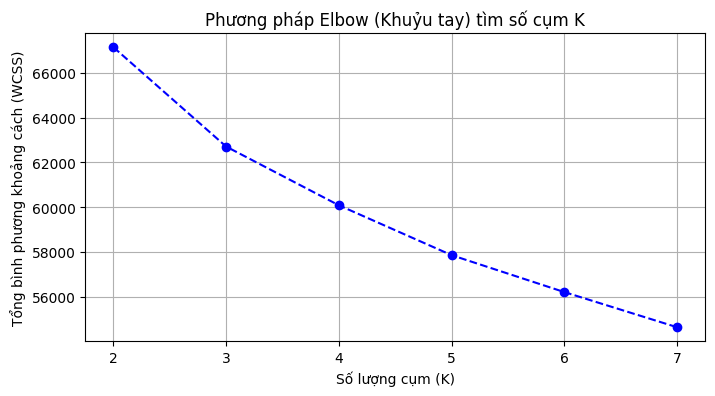

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("1. Đang đọc dữ liệu dạng số từ data/processed/...")
df_ml = pd.read_csv('data/processed/hr_ml_encoded.csv')

# Bỏ cột mục tiêu 'Attrition' vì phân cụm là Học không giám sát
if 'Attrition' in df_ml.columns:
    X_cluster = df_ml.drop(columns=['Attrition'])
else:
    X_cluster = df_ml.copy()

print("2. Đang chuẩn hóa dữ liệu bằng StandardScaler...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("3. Đang tính toán phương pháp Elbow để tìm K tối ưu...")
wcss = [] 
K_range = range(2, 8)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Phương pháp Elbow (Khuỷu tay) tìm số cụm K')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Tổng bình phương khoảng cách (WCSS)')
plt.grid(True)
plt.show()

## 2.1 Chạy K-Means với K=3 và xuất Bảng Profiling
Dựa vào biểu đồ Elbow, chọn K=3 là số cụm tối ưu.

In [22]:
OPTIMAL_K = 3
print(f"4. Tiến hành phân cụm với K = {OPTIMAL_K}...")

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled) 

# Gắn nhãn cụm vào dataframe gốc
df_profile = X_cluster.copy()
df_profile['Cluster'] = cluster_labels
if 'Attrition' in df_ml.columns:
    df_profile['Attrition'] = df_ml['Attrition'] 

print("\n5. BẢNG PROFILING CHÂN DUNG CÁC CỤM (Trung bình các đặc trưng):")
key_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome', 'Cluster']
if 'Attrition' in df_profile.columns:
    key_cols.append('Attrition')

# Tính trung bình theo cụm
cluster_summary = df_profile[key_cols].groupby('Cluster').mean().round(2)
display(cluster_summary)

4. Tiến hành phân cụm với K = 3...

5. BẢNG PROFILING CHÂN DUNG CÁC CỤM (Trung bình các đặc trưng):


,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,DistanceFromHome,Attrition
Cluster,,,,,,
0,35.13,5874.04,9.29,6.12,9.35,0.22
1,34.90,4279.40,8.55,5.50,9.28,0.16
2,47.07,15453.42,24.36,13.99,8.93,0.07


## 2.2 Trực quan hóa Đặc trưng từng Cụm
**Biểu đồ 1: So sánh Mức lương (MonthlyIncome)**

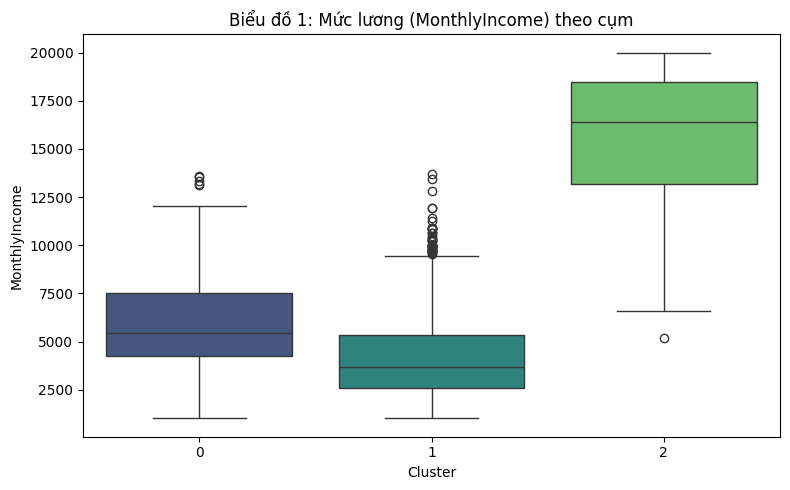

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_profile, x='Cluster', y='MonthlyIncome', palette='viridis')
plt.title('Biểu đồ 1: Mức lương (MonthlyIncome) theo cụm')
plt.tight_layout()
plt.show()

**Biểu đồ 2: So sánh Độ tuổi (Age)**

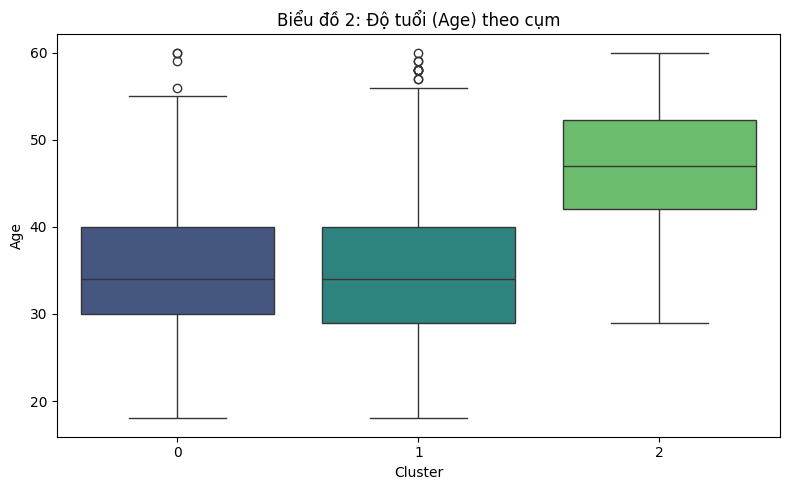

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_profile, x='Cluster', y='Age', palette='viridis')
plt.title('Biểu đồ 2: Độ tuổi (Age) theo cụm')
plt.tight_layout()
plt.show()

**Biểu đồ 3: So sánh Tổng số năm kinh nghiệm (TotalWorkingYears)**

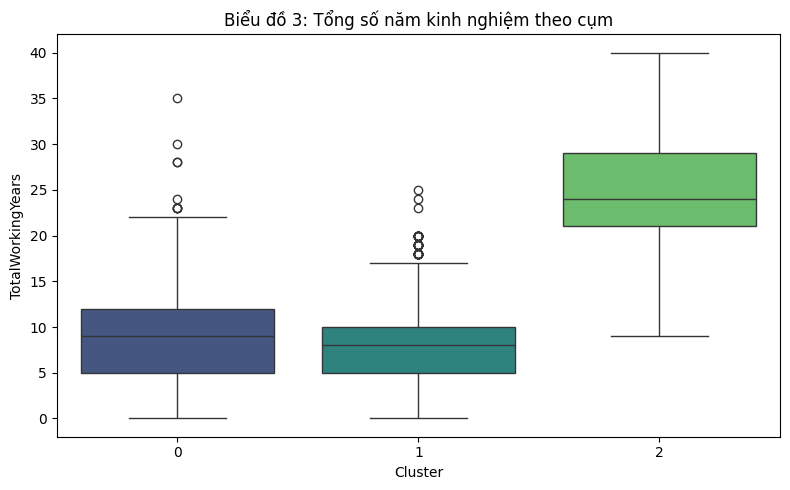

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_profile, x='Cluster', y='TotalWorkingYears', palette='viridis')
plt.title('Biểu đồ 3: Tổng số năm kinh nghiệm theo cụm')
plt.tight_layout()
plt.show()

## 2.3 Lưu Mô hình và Dữ liệu (Yêu cầu bắt buộc)

In [25]:
# Lưu mô hình và dữ liệu
os.makedirs('outputs/models', exist_ok=True)
joblib.dump(scaler, 'outputs/models/scaler_kmeans.pkl')
joblib.dump(kmeans, 'outputs/models/kmeans_model.pkl')

processed_dir = 'data/processed'
df_profile.to_csv(f'{processed_dir}/hr_clustered.csv', index=False)

print("6. Đã lưu thành công mô hình vào 'outputs/models/' và dữ liệu phân cụm vào 'data/processed/'.")

6. Đã lưu thành công mô hình vào 'outputs/models/' và dữ liệu phân cụm vào 'data/processed/'.
